This code details back testing

In [12]:
import bt
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
# Set rolling window parameters
years = 15
window_days = years * 252

# Define start and end dates for full dataset
startDate = '2010-02-28'
endDate = '2026-02-01'

Here we import all of the required data, scraped from google finance, doing this as a single step ensures that we dont run into usage probelems

In [13]:
# S&P 500
sp500_data = bt.get('^GSPC', start=startDate, end=endDate) 
# Gold 
gold_data = bt.get('gold', start=startDate, end=endDate)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In this section we generate and simulate the various equities 

In [14]:
##########################
# --- S&P 500 ---
##########################

sp500_returns = sp500_data.pct_change().dropna()
daily_dividend_yield = (1 + 0.015)**(1 / 252) - 1
daily_expense_ratio = (1 - 0.01)**(1 / 252) - 1
sp500_total_returns = (1 + sp500_returns) * (1 + daily_dividend_yield) - 1
spy =  (1 + sp500_total_returns).cumprod() * sp500_data.iloc[0]

##########################
# --- TRUE UPRO PROXY ---
##########################

# Parameters
leverage = 3.0
expense_ratio_annual = 0.009  # 0.9%
financing_spread_annual = 0.015  # realistic borrowing cost (~1.5%)
total_cost_annual = expense_ratio_annual + financing_spread_annual

daily_cost = (1 + total_cost_annual)**(1/252) - 1

# Volatility drag aware compounding
leveraged_spy_returns = (1 + leverage * sp500_returns) * (1 - daily_cost) - 1

# Prevent pathological blowups (realistic floor)
leveraged_spy_returns = np.clip(leveraged_spy_returns, -0.95, None)
leveraged_spy_prices = (1 + leveraged_spy_returns).cumprod() * sp500_data.iloc[0]


# --- Gold ---
gold_returns = gold_data.pct_change().dropna()
gold_etf_returns = gold_returns  # No fee applied
gld_data = (1 + gold_etf_returns).cumprod() * gold_data.iloc[0]

##########################
# --- Property Funding ---
##########################
'''
# Parameters
annual_growth = 0.08
tax_rate = 0.45
trading_days = 252

# Apply tax on the compound gain
after_tax_annual_return = ((1 + annual_growth) ** (1 - tax_rate)) - 1

# Convert to daily growth rate
daily_growth_rate = (1 + after_tax_annual_return) ** (1 / trading_days) - 1

# Generate daily returns and prices
new_stock_returns = pd.Series(daily_growth_rate, index=sp500_data.index)
new_stock_prices = (1 + new_stock_returns).cumprod() * 100'''

'\n# Parameters\nannual_growth = 0.08\ntax_rate = 0.45\ntrading_days = 252\n\n# Apply tax on the compound gain\nafter_tax_annual_return = ((1 + annual_growth) ** (1 - tax_rate)) - 1\n\n# Convert to daily growth rate\ndaily_growth_rate = (1 + after_tax_annual_return) ** (1 / trading_days) - 1\n\n# Generate daily returns and prices\nnew_stock_returns = pd.Series(daily_growth_rate, index=sp500_data.index)\nnew_stock_prices = (1 + new_stock_returns).cumprod() * 100'

Define common helper functions

In [15]:
def calculate_cagr(series):
    n = len(series) / 252
    # Use .iloc[0] for the first item and .iloc[-1] for the last
    return (series.iloc[-1] / series.iloc[0]) ** (1 / n) - 1

def calculate_max_drawdown(prices):
    # Ensure this function also uses .iloc if it does direct indexing
    peak = prices.expanding(min_periods=1).max()
    drawdown = (prices / peak) - 1
    return drawdown.min()

Create Data frames and run tests

In [16]:
import pandas as pd
import numpy as np
import bt
from joblib import Parallel, delayed
from tqdm import tqdm

# ==========================================
# 1. PREPARE DATAFRAMES
# ==========================================
# Use how='all' so we only drop days where the ENTIRE market was closed
data_full_1 = pd.DataFrame({
    'leveraged_spy': leveraged_spy_prices.squeeze(),
    'gld' : gld_data.squeeze(),
}).ffill().dropna(how='all') 

data_full_2 = pd.DataFrame({
    'leveraged_spy': leveraged_spy_prices.squeeze(),
    'gld': gld_data.squeeze(),
    'spy': spy.squeeze(),
}).ffill().dropna(how='all')

# ==========================================
# 2. CALCULATE ROLLING WINDOWS
# ==========================================
rolling_starts = pd.date_range(start=startDate, end=endDate, freq='B') 

valid_starts = []
for start in rolling_starts:
    end = start + pd.DateOffset(years=years)
    if end > data_full_1.index[-1]:
        continue
    data_slice = data_full_1.loc[start:end]
    if len(data_slice) < int(window_days * 0.95):
        continue
    valid_starts.append(start)

# ==========================================
# 3. CUSTOM ALGOS
# ==========================================
class RebalanceQuarterly(bt.Algo):
    def __init__(self, interval=63):
        super().__init__()
        self.last_rebalance_date = None
        self.interval = interval

    def __call__(self, target):
        if target.now is None:
            return True

        if self.last_rebalance_date is None or (target.now - self.last_rebalance_date).days >= self.interval:
            self.last_rebalance_date = target.now
            return bt.algos.Rebalance()(target)

        return True

class FixedPartialWeight(bt.Algo):
    """
    Assigns a fixed weight to one asset and evenly splits the remainder across others.
    """
    def __init__(self, fixed_asset, fixed_weight):
        super().__init__()
        self.fixed_asset = fixed_asset
        self.fixed_weight = fixed_weight

    def __call__(self, target):
        selected = list(target.temp.get('selected', []))
        if not selected or self.fixed_asset not in selected:
            return True  # Exit early if nothing to do

        weights = {}
        others = [a for a in selected if a != self.fixed_asset]

        if others:
            equal_weight = (1.0 - self.fixed_weight) / len(others)
            for asset in others:
                weights[asset] = equal_weight
        weights[self.fixed_asset] = self.fixed_weight

        target.temp['weights'] = weights
        return True

import os
from contextlib import redirect_stdout, redirect_stderr

# ==========================================
# 4. PARALLEL WORKER FUNCTION
# ==========================================
def run_single_rolling_window(start):
    end = start + pd.DateOffset(years=years)
    data_slice = data_full_1.loc[start:end]
    data_slice_2 = data_full_2.loc[start:end]

    strat1 = bt.Strategy('combined', [
        bt.algos.RunEveryNPeriods(28),
        bt.algos.SelectAll(),
        bt.algos.WeighEqually(),
        RebalanceQuarterly(interval=63)
    ])

    strat2 = bt.Strategy('combined_prop', [
        bt.algos.RunEveryNPeriods(28),
        bt.algos.SelectAll(),
        FixedPartialWeight(fixed_asset='spy', fixed_weight=0.7),
        RebalanceQuarterly(interval=63)
    ])

    # Mute standard output and standard error so internal bt progress bars don't print
    with open(os.devnull, 'w') as f, redirect_stdout(f), redirect_stderr(f):
        res1 = bt.run(bt.Backtest(strat1, data_slice))
        res2 = bt.run(bt.Backtest(strat2, data_slice_2))

    return {
        'start': start,
        'end': end,
        'CAGR_S1': np.float64(res1.stats.loc['cagr'].values[0]),
        'MDD_S1': np.float64(res1.stats.loc['max_drawdown'].values[0]),
        'CAGR_S2': np.float64(res2.stats.loc['cagr'].values[0]),
        'MDD_S2': np.float64(res2.stats.loc['max_drawdown'].values[0])
    }

# ==========================================
# 5. EXECUTE PARALLEL ROLLING BACKTESTS
# ==========================================
from joblib import Parallel, delayed
import joblib
import contextlib
from tqdm import tqdm

# This creates a bridge between joblib and tqdm so you get a live progress bar
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

print(f"Starting parallel backtests across {len(valid_starts)} windows...")

# Run joblib wrapped in the tqdm progress bar
# TIP: If your computer freezes or you get a memory error, change n_jobs=-1 to n_jobs=4
with tqdm_joblib(tqdm(desc="Rolling Windows", total=len(valid_starts), unit="window")):
    raw_results = Parallel(n_jobs=6)(
        delayed(run_single_rolling_window)(s) for s in valid_starts
    )

results_df_all = pd.DataFrame(raw_results)

# Split back into original `results` and `results2` lists so plotting code doesn't break
results = results_df_all[['start', 'end', 'CAGR_S1', 'MDD_S1']].rename(
    columns={'CAGR_S1': 'CAGR', 'MDD_S1': 'Max Drawdown'}
).to_dict('records')

results2 = results_df_all[['start', 'end', 'CAGR_S2', 'MDD_S2']].rename(
    columns={'CAGR_S2': 'CAGR', 'MDD_S2': 'Max Drawdown'}
).to_dict('records')

print("✅ Parallel processing complete.")

# ==========================================
# 6. EXECUTE FULL-PERIOD BENCHMARKS
# ==========================================
s3 = bt.Strategy('upro', [
    bt.algos.RunEveryNPeriods(28),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    RebalanceQuarterly(interval=63)
])

s4 = bt.Strategy('spy', [
    bt.algos.RunEveryNPeriods(28),
    bt.algos.SelectAll(),
    bt.algos.WeighEqually(),
    RebalanceQuarterly(interval=63)
])

# Because they are already DataFrames, we just copy and rename the columns 
# so the 'bt' engine recognizes the assets correctly.
upro_df = leveraged_spy_prices.copy()
upro_df.columns = ['upro']

spy_df = spy.copy()
spy_df.columns = ['spy']

# Pass the cleaned DataFrames into the Backtest
test3 = bt.Backtest(s3, upro_df)
test4 = bt.Backtest(s4, spy_df)

res3 = bt.run(test3)
res4 = bt.run(test4)

print("✅ Benchmarks (UPRO & SPY) calculated. Ready for plotting.")

Starting parallel backtests across 240 windows...


Rolling Windows: 100%|██████████| 240/240 [01:19<00:00,  3.97window/s]

✅ Parallel processing complete.


100%|██████████| 1/1 [00:00<00:00,  2.16it/s]

✅ Benchmarks (UPRO & SPY) calculated. Ready for plotting.


Stats and data prep 

In [17]:
# Calculate CAGR and Max Drawdown for UPRO and SPY
cagr_s3 = res3['upro'].prices.rolling(window=window_days).apply(calculate_cagr)
cagr_s4 = res4['spy'].prices.rolling(window=window_days).apply(calculate_cagr)
mdd_upro = res3['upro'].prices.rolling(window=window_days).apply(calculate_max_drawdown)
mdd_spy = res4['spy'].prices.rolling(window=window_days).apply(calculate_max_drawdown)

# Convert simulation results to DataFrames
results_df = pd.DataFrame(results)
results_df2 = pd.DataFrame(results2)

# Adjust start dates to reflect rolling window (shifting to the end of the window)
results_df['start'] = results_df['start'] + pd.DateOffset(years=years)
results_df2['start'] = results_df2['start'] + pd.DateOffset(years=years)

# Create a dictionary for easier iterative plotting/printing
strategies = {
    '50% UPRO + 50% GOLD': results_df['CAGR'],
    '15% UPRO + 15% GOLD + 70% spy': results_df2['CAGR'],
    'UPRO': cagr_s3,
    'SPY': cagr_s4
}

# Define standard colors for consistency across all plots
gld_upro_color = '#2980B9'
upro_color = '#27AE60'
spy_color = '#E67E22'
results2_color = '#9B59B6'
strategy_colors = [gld_upro_color, results2_color, upro_color, spy_color]

Export data to csv

In [18]:
from backtest_export import BacktestExporter

# Toggling for automated saving
SAVE_OUTPUTS = True

# Initialize the exporter with backtest parameters
exporter = BacktestExporter(years=years, startDate=startDate, endDate=endDate, save_outputs=SAVE_OUTPUTS)

# Perform optimized vectorized CSV export (instant vs hours)
exporter.export_csv(results_df, results_df2, cagr_s3, mdd_upro, cagr_s4, mdd_spy)

📁 Output directory created: BT_15y_2010-02-28_to_2026-02-01_20260403_121146
⏳ Vectorizing data for export...
✅ CSV saved: BT_15y_2010-02-28_to_2026-02-01_20260403_121146/rolling_stats_results.csv


Visualisation (Break up when have time)

In [19]:
import seaborn as sns

# 1. PRINT SUMMARY STATISTICS
print("\n--- Median & Lower Quartile CAGR by Strategy ---")
for name, series in strategies.items():
    print(f"{name}:")
    print(f"  Median CAGR: {series.median():.2%}")
    print(f"  Lower Quartile CAGR: {series.quantile(0.25):.2%}\n")
    


--- Median & Lower Quartile CAGR by Strategy ---
50% UPRO + 50% GOLD:
  Median CAGR: 27.99%
  Lower Quartile CAGR: 26.48%

15% UPRO + 15% GOLD + 70% spy:
  Median CAGR: 18.59%
  Lower Quartile CAGR: 17.92%

UPRO:
  Median CAGR: 25.67%
  Lower Quartile CAGR: 24.32%

SPY:
  Median CAGR: 13.85%
  Lower Quartile CAGR: 13.49%



Rolling CAGR, demonstrated CAGR at each date looking backwards

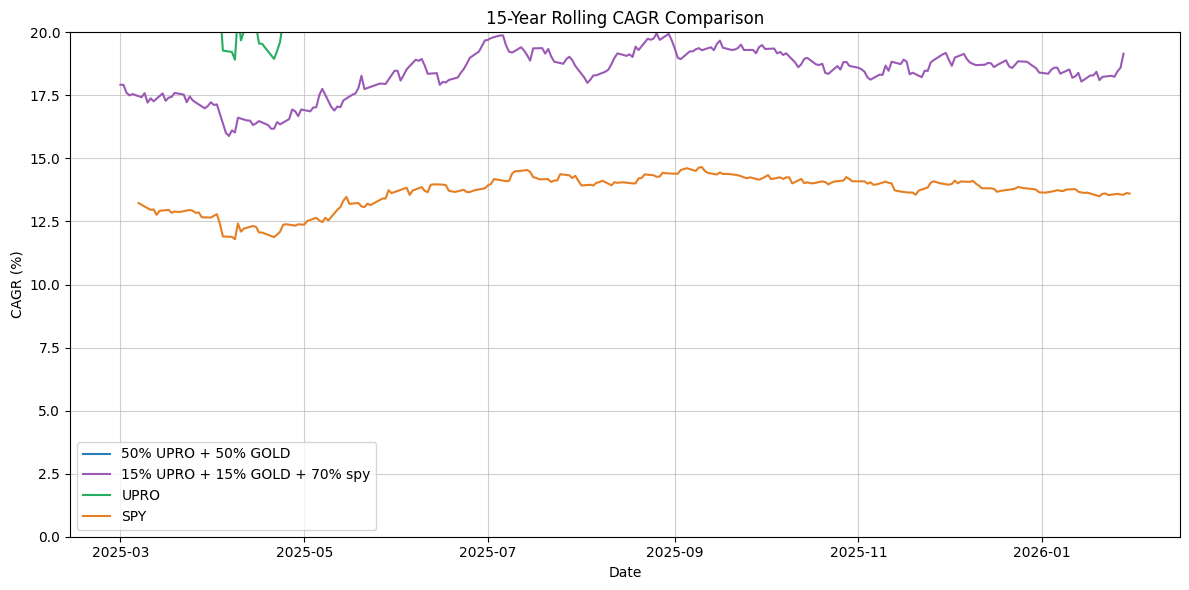

In [20]:
# 2. ROLLING CAGR LINE PLOT
plt.figure(figsize=(12, 6))
plt.plot(results_df['start'], 100 * results_df['CAGR'], label='50% UPRO + 50% GOLD', color=gld_upro_color)
plt.plot(results_df2['start'], 100 * results_df2['CAGR'], label='15% UPRO + 15% GOLD + 70% spy', color=results2_color)
plt.plot(100 * cagr_s3, label='UPRO', color=upro_color)
plt.plot(100 * cagr_s4, label='SPY', color=spy_color)
plt.xlabel('Date')
plt.ylabel('CAGR (%)')
plt.title(f'{years}-Year Rolling CAGR Comparison')
plt.ylim(0, 20)
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Rolling Max drawdown 

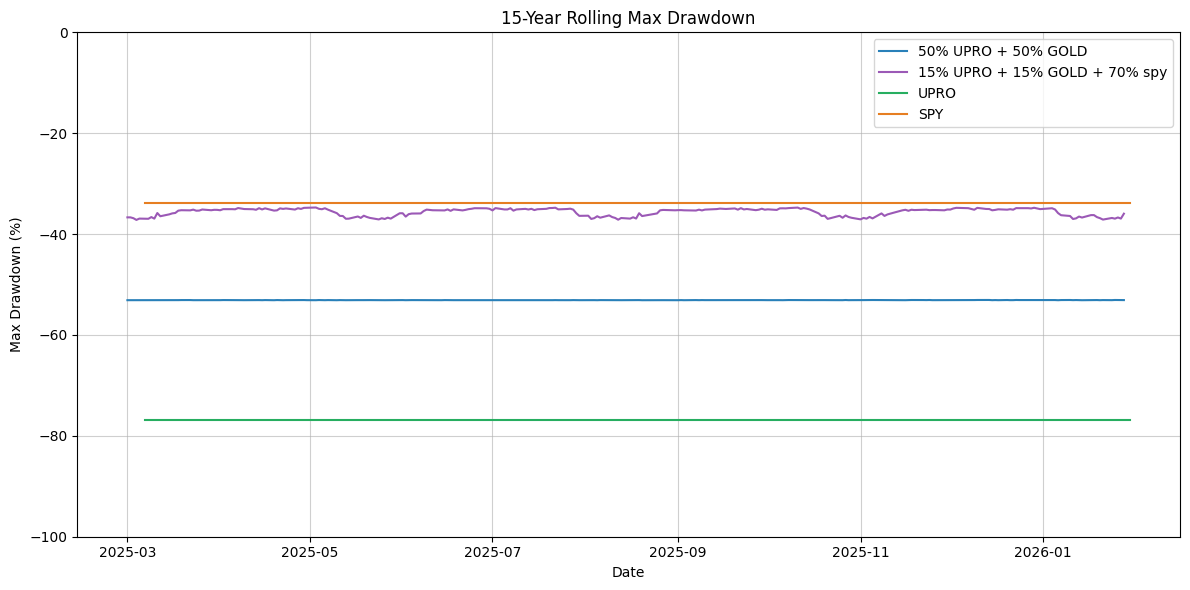

In [21]:
# 3. ROLLING MAX DRAWDOWN PLOT
plt.figure(figsize=(12, 6))
plt.plot(results_df['start'], 100 * results_df['Max Drawdown'], label='50% UPRO + 50% GOLD', color=gld_upro_color)
plt.plot(results_df2['start'], 100 * results_df2['Max Drawdown'], label='15% UPRO + 15% GOLD + 70% spy', color=results2_color)
plt.plot(mdd_upro.index, 100 * mdd_upro, label='UPRO', color=upro_color)
plt.plot(mdd_spy.index, 100 * mdd_spy, label='SPY', color=spy_color)
plt.xlabel('Date')
plt.ylabel('Max Drawdown (%)')
plt.title(f'{years}-Year Rolling Max Drawdown')
plt.ylim(-100, 0)
plt.grid(True, alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Mean CAGR With Bar chart

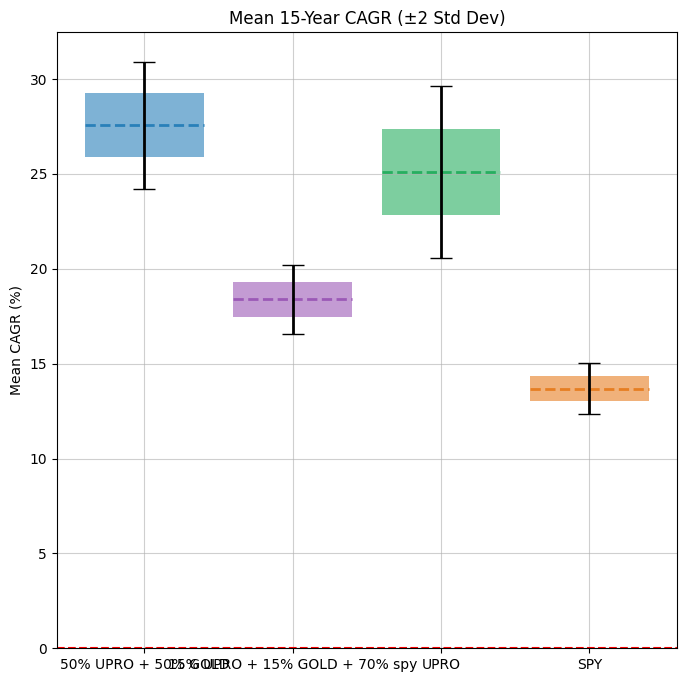

In [22]:
# 4. MEAN CAGR BAR CHART WITH STD ERRORS
means = [100 * s.mean() for s in strategies.values()]
stds = [100 * s.std() for s in strategies.values()]
plt.figure(figsize=(8, 8))
bars = plt.bar(strategies.keys(), means, color='white', edgecolor='white', linewidth=1.5)
for i, bar in enumerate(bars):
    plt.bar(bar.get_x() + bar.get_width() / 2, 2 * stds[i], bottom=means[i] - stds[i], color=strategy_colors[i], alpha=0.6, width=bar.get_width())
    plt.plot([bar.get_x(), bar.get_x() + bar.get_width()], [means[i], means[i]], color=strategy_colors[i], linestyle='--', linewidth=2)
    plt.errorbar(bar.get_x() + bar.get_width() / 2, means[i], yerr=2 * stds[i], fmt='none', ecolor='black', capsize=8, linewidth=2)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
plt.ylabel('Mean CAGR (%)')
plt.title(f'Mean {years}-Year CAGR (±2 Std Dev)')
plt.grid(True, alpha=0.6)
plt.show()

Histogams baby

📉 Plot persisted: rolling_cagr_comparison.png


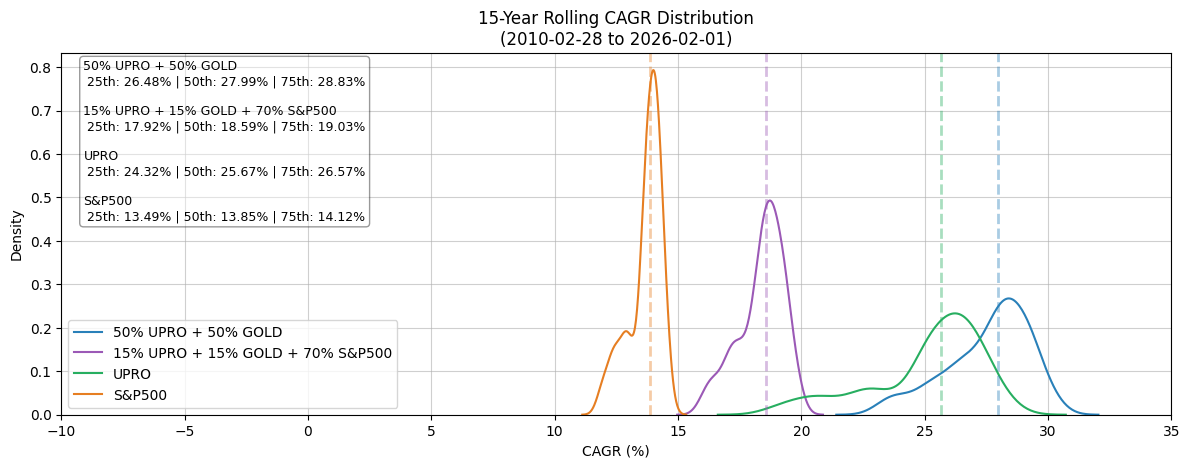

In [23]:
def save_plot(name): exporter.save_plot(name)

# 5. HISTOGRAM + KDE DISTRIBUTION
plt.figure(figsize=(12, 6))
numBins = '30'
sns.kdeplot(100 * results_df['CAGR'], color=gld_upro_color, label='50% UPRO + 50% GOLD', fill=False)
sns.kdeplot(100 * results_df2['CAGR'], color=results2_color, label='15% UPRO + 15% GOLD + 70% S&P500', fill=False)
sns.kdeplot(100 * cagr_s3.dropna(), color=upro_color, label='UPRO', fill=False)
sns.kdeplot(100 * cagr_s4.dropna(), color=spy_color, label='S&P500', fill=False)

plt.xlabel('CAGR (%)')
plt.title(f'{years}-Year Rolling CAGR Distribution\n({startDate} to {endDate})')
plt.legend()

plt.grid(True, alpha=0.6)
plt.xlim(-10, 35)

# Median lines
plt.axvline(100 * results_df['CAGR'].median(), color=gld_upro_color, linestyle='--', linewidth=2, alpha=0.4)
plt.axvline(100 * results_df2['CAGR'].median(), color=results2_color, linestyle='--', linewidth=2, alpha=0.4)
plt.axvline(100 * cagr_s3.dropna().median(), color=upro_color, linestyle='--', linewidth=2, alpha=0.4 )
plt.axvline(100 * cagr_s4.dropna().median(), color=spy_color, linestyle='--', linewidth=2, alpha = 0.4)

def get_percentile_text(name, data):
    data = 100 * data.dropna()
    p25, p50, p75 = np.percentile(data, [25, 50, 75])
    return f"{name}\n 25th: {p25:.2f}% | 50th: {p50:.2f}% | 75th: {p75:.2f}%"

text_block = "\n\n".join([
    get_percentile_text("50% UPRO + 50% GOLD", results_df['CAGR']),
    get_percentile_text("15% UPRO + 15% GOLD + 70% S&P500", results_df2['CAGR']),
    get_percentile_text("UPRO", cagr_s3),
    get_percentile_text("S&P500", cagr_s4),
])

plt.gca().text(
    0.02, 0.98, text_block,
    transform=plt.gca().transAxes,
    fontsize=9,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.4)
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
save_plot('rolling_cagr_comparison')
plt.show()